In [3]:
import pandas as pd
import pandas.util.testing as tm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

/var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/ipykernel_7182/39937593.py:2: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [4]:
# import files for analysis
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)
clin = clin.drop(labels = [1578], axis = 0)
print(clin.shape)
clin.shape
print(prot.shape)

# read MODS
mods = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/New.MODS.groups(2022).csv', index_col=0, header=0)
print("unique names:", mods['MODS.group'].unique())

(414, 38)
(414, 4979)
unique names: ['NO MODS' 'Short MODS' 'Prolonged MODS' 'Early Death' 'Late Death']


In [5]:
# make groups for later
list_groups = []
for i in clin['iss']:
    if i<=3:
        list_groups.append("Control")
    elif i >3 and i<=5:
        list_groups.append("Low")
    elif i>5 and i<=15:
        list_groups.append("Mild")
    elif i>15 and i<25:
        list_groups.append("Moderate")
    elif i>=25:
        list_groups.append("Critical")

groups = pd.DataFrame(list_groups)
print(groups.value_counts())

Critical    108
Mild         94
Moderate     77
Control      73
Low          62
dtype: int64


In [6]:
groups = groups.set_index(clin.index)
clin =  clin.join(groups)

In [7]:
prot['MMP9.2579.17']

TubeUniqueID
1870     54823.4
1822     69241.0
326      85553.8
304     116511.7
165      42721.4
          ...   
1734    101080.8
311     110354.8
66       72780.0
717      25907.8
1911     65149.2
Name: MMP9.2579.17, Length: 414, dtype: float64

In [8]:
# select a list of markers
list_markers = ["ANGPT1.2811.27", "ANGPTL1.11142.11",  "ANGPTL3.10391.1","ANGPTL4.3796.79",
                "ANGPT2.2602.2","ANGPT4.2500.2", "ANG.4874.3","ANGPTL7.6371.50","TIE1.2844.53",
                "ICAM2.5486.73","ICAM3.2649.77","ICAM4.6550.4", 
                "ICAM5.8245.27", "VCAM1.2967.8","PECAM1.2695.25","MMP1.4924.32", "MMP2.4160.49","MMP3.2788.55",  
                "MMP7.2789.26","MMP8.9172.69","MMP9.2579.17","MMP10.8479.4","MMP12.4496.60", "MMP13.4925.54","MMP14.5002.76", 
                "MMP16.5268.49","MMP16.9719.145","MMP17.2838.53", "MMP19.6425.87", "MMP20.15419.15",
                 "VEGFA.19437.61", "VEGFA.2597.8", "VEGFA.4867.15", "VEGFB.9453.12",
                "VEGFC.3132.1", "IL1B.3037.62", "IL4.2906.55","IL5.11071.1","IL6.4673.13", 
                "IL6ST.2620.4", "IL10.2773.50", "IL12B.13733.5",
                "IL12B.IL23A.10365.132", "IL13.3072.4", "IL17A.9170.24", "IL17B.3499.77", 
                "IL17C.9255.5", "IL17F.14026.24",  "SAA1.15515.2", "ADAM11.6586.19", "CD44.9283.8",
                 "SAA2.18832.65", "SAA4.15516.12","KNG1.15343.337","KNG1.19631.13", "KNG1.7784.1", 
                "CD99L2.10539.30", "CCL5.5480.49", 
                "PLG.3710.49", "PLG.4150.75", "PLG.4151.6", "PLAT.2212.69",
                "FGA.FGB.FGG.2796.62", "FGA.FGB.FGG.4907.56","PROC.2961.1","PROC.3758.68",
                "SERPINC1.3344.60","SERPINE1.2925.9",  "SERPINE2.19154.41", "SERPINF2.3024.18", "S100A10.15318.75","CPB2.3518.54",
                "F2.4157.2", "F2.5316.54", "F5.4906.35", "F7.3184.25","F8.13499.30","F9.4876.32", "F10.3077.66","F11.2190.55","F13A1.F13B.16927.9","VWF.3050.7",
                "ACE.10714.7","ACE2.2805.6"]   

clin['mortality'] = clin['28_day_mortality'].replace({1:0,  0:1})
print(len(list_markers))
biomarkers = prot.filter(items = list_markers)

84


In [9]:
short_name =[]
for i in list_markers:
    # print(i.split(".")[0])
    short_name.append(i)
df_total = pd.DataFrame(short_name, columns = ["Protein_name"])

In [10]:
df_total.to_csv("/Users/smasarone/Documents/table_endothelial_prot.csv")

In [11]:
# preprocess
scaler = MinMaxScaler()
scaler.fit(biomarkers)
X= scaler.transform(biomarkers)
X= pd.DataFrame(X)
X.columns= biomarkers.columns
X = X.set_index(prot.index)

In [12]:
# In this section I want to compare the expression of these markers in each category of outcome
prot_df= X.filter(items=list_markers, axis = 1)
df_no_mods = prot_df.filter(items = mods[mods['MODS.group']=='NO MODS'].index, axis = 0)
print("No MODS", df_no_mods.shape)

df_short_mods = prot_df.filter(items = mods[mods['MODS.group']=='Short MODS'].index, axis = 0)
print("short MODS", df_short_mods.shape)

df_long_mods = prot_df.filter(items = mods[mods['MODS.group']=='Prolonged MODS'].index, axis = 0)
print("Prol MODS", df_long_mods.shape)


No MODS (314, 84)
short MODS (53, 84)
Prol MODS (21, 84)


In [13]:
groups = mods['MODS.group'].unique()
combinations = itertools.combinations(groups, 2) # we look at pairs
for combination in combinations:
    print(combination)

ls = list(range(1, 5 + 1))
combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
for combination in combinations:
    print(combination)  

X['mods'] = mods['MODS.group']

('NO MODS', 'Short MODS')
('NO MODS', 'Prolonged MODS')
('NO MODS', 'Early Death')
('NO MODS', 'Late Death')
('Short MODS', 'Prolonged MODS')
('Short MODS', 'Early Death')
('Short MODS', 'Late Death')
('Prolonged MODS', 'Early Death')
('Prolonged MODS', 'Late Death')
('Early Death', 'Late Death')
(1, 5)
(1, 4)
(2, 5)
(1, 3)
(2, 4)
(3, 5)
(1, 2)
(2, 3)
(3, 4)
(4, 5)


In [14]:
# We should check where we have the highest p-value and hence significnce. 
# So we are checking what proteins are the most different between different groups

significant_combinations={"name":[], 
                         "combination":[],
                         "pval":[]}
for col in list_markers:
    
    data = [
    X[X['mods']=='NO MODS'][col],
    X[X['mods']=='Short MODS'][col],
    X[X['mods']=='Prolonged MODS'][col],
    X[X['mods']=='Early Death'][col],
    X[X['mods']=='Late Death'][col]]

    ls = list(range(1, len(data) + 1))
    combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
    for combination in combinations:
        data1 = data[combination[0] - 1]
        data2 = data[combination[1] - 1]
        U, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        if p <= 0.0006: 
            significant_combinations['name'].append(col)
            significant_combinations['combination'].append(combination)
            significant_combinations['pval'].append(p)

print("Unique proteins differently expressed:", len(pd.Series(significant_combinations['name']).unique()))

Unique proteins differently expressed: 35


In [15]:
#create a df so it's easier to find the top expressed proteins
endot_df = pd.DataFrame(significant_combinations['name'])
endot_df['combination'] = significant_combinations['combination']
endot_df['pval'] = significant_combinations['pval'] 

idx_smallest10pval = endot_df['pval'].sort_values()[0:30].index
endot_df.iloc[idx_smallest10pval, :]

,0,combination,pval
32,PROC.3758.68,"(1, 4)",8.968562e-10
25,PLG.4151.6,"(1, 4)",5.895033e-09
39,SERPINF2.3024.18,"(1, 4)",1.460151e-08
33,PROC.3758.68,"(1, 3)",3.837483e-08
42,SERPINF2.3024.18,"(1, 2)",5.074046e-08
19,IL6.4673.13,"(1, 2)",2.947953e-07
17,IL6.4673.13,"(1, 4)",1.192294e-06
6,MMP8.9172.69,"(1, 4)",2.058215e-06
35,PROC.3758.68,"(1, 2)",3.514301e-06
34,PROC.3758.68,"(2, 4)",3.668958e-06


In [46]:
# utils funct
def plot_graph_prot(col):
    
    data = [
        X[X['mods']=='NO MODS'][col],
        X[X['mods']=='Short MODS'][col],
        X[X['mods']=='Prolonged MODS'][col],
        X[X['mods']=='Early Death'][col],
        X[X['mods']=='Late Death'][col],
    ]
    significant_combinations = []

    # Check from the outside pairs of boxes inwards
    ls = list(range(1, len(data) + 1))
    combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
    for combination in combinations:
        data1 = data[combination[0] - 1]
        data2 = data[combination[1] - 1]
        # Significance
        U, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        if p < 0.0006: # here we are using this because we are correcting with bonferroni
            significant_combinations.append([combination, p])

    print(significant_combinations)
    ax = plt.axes()
    bp = ax.boxplot(data, widths=0.6, patch_artist=True)
    ax.set_title('MODS - '+col.split(".")[0], fontsize=12)
    ax.set_ylabel("Expression")
    xticklabels = X['mods']
    xticklabels = ["No MODS", 'Short MODS', "Prol. MODS", "Early Death", 'Late Death']
    ax.set_xticklabels(xticklabels)
    ax.tick_params(axis='x', which='major', length=0)
    xticks = [0.5] + [x + 0.5 for x in ax.get_xticks()]
    ax.yaxis.grid(True)
    ax.xaxis.grid(True)
    ax.set_xticks(xticks, minor=True)
    ax.tick_params(axis='x', which='minor', length=3, width=1) 

    # Change the colour of the boxes to Seaborn's 'magma' palette
    colors = sns.color_palette('magma')
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    plt.setp(bp['medians'], color='k')

    bottom, top = ax.get_ylim()
    y_range = top - bottom

    # Significance bars
    for i, significant_combination in enumerate(significant_combinations):
        x1 = significant_combination[0][0]
        x2 = significant_combination[0][1]
        level = len(significant_combinations) - i
        bar_height = (y_range * 0.07 * level) + top
        bar_tips = bar_height - (y_range * 0.02)
        plt.plot(
            [x1, x1, x2, x2],
            [bar_tips, bar_height, bar_height, bar_tips], lw=1, c='k'
        )
        # Significance level
        p = significant_combination[1]
        if p < 0.0001:
            sig_symbol = '***'
        elif p < 0.005:
            sig_symbol = '**'
        elif p < 0.05:
            sig_symbol = '*'
        text_height = bar_height + (y_range * 0.004)
        plt.text((x1 + x2) * 0.5, text_height, sig_symbol, ha='center', va='bottom', c='k')
    
    #plt.savefig(col+".pdf")
    return plt.show()


[[(1, 3), 0.00022641727730989523]]


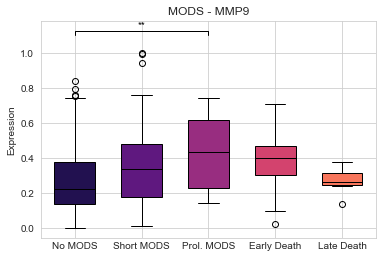

In [58]:
# plot 
plot_graph_prot("MMP9.2579.17")

In [18]:
# implementing the correction
new_threshold = 0.05/84
print("new threshold:",new_threshold)

# so now we can get some sort of stats for the couples that are more frequently different
endot_df['combination'].value_counts(normalize=True)

new threshold: 0.0005952380952380953


(1, 4)    0.566038
(1, 2)    0.207547
(1, 3)    0.075472
(2, 4)    0.075472
(1, 5)    0.056604
(3, 4)    0.018868
Name: combination, dtype: float64

<AxesSubplot:title={'center':'Couples most differentially expr.'}, xlabel='combination', ylabel='count'>

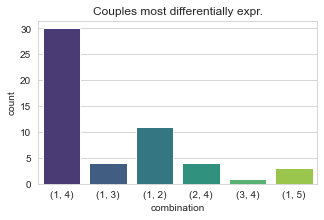

In [19]:
# plot the frequency
sns.set_style("whitegrid")
plt.figure(figsize = (5, 3))
plt.title("Couples most differentially expr.")
sns.countplot(x = endot_df['combination'], palette = 'viridis')


In [20]:
# proteins that change between 1 and 4
endot_df.columns = ['name', 'combination', 'pval']
endot_df[endot_df['combination']==(1,4)]['name'].unique()

array(['ANGPTL4.3796.79', 'ANGPT2.2602.2', 'ANGPT4.2500.2',
       'ANGPTL7.6371.50', 'ICAM3.2649.77', 'PECAM1.2695.25',
       'MMP8.9172.69', 'MMP10.8479.4', 'MMP12.4496.60', 'MMP13.4925.54',
       'MMP16.5268.49', 'MMP17.2838.53', 'VEGFA.2597.8', 'VEGFC.3132.1',
       'IL1B.3037.62', 'IL4.2906.55', 'IL6.4673.13', 'IL17A.9170.24',
       'IL17F.14026.24', 'KNG1.7784.1', 'PLG.4150.75', 'PLG.4151.6',
       'PROC.2961.1', 'PROC.3758.68', 'SERPINC1.3344.60',
       'SERPINF2.3024.18', 'CPB2.3518.54', 'F2.4157.2', 'F2.5316.54',
       'F11.2190.55'], dtype=object)

[[(1, 4), 7.439522625321382e-05]]


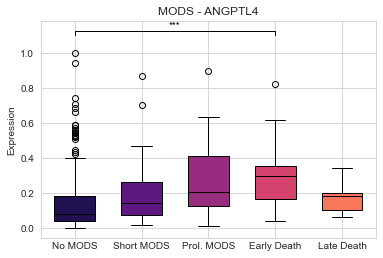

[[(1, 4), 0.0001384889143745364]]


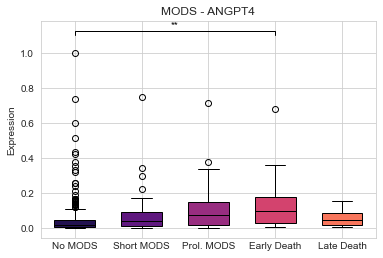

[[(1, 4), 2.6860692669036224e-05]]


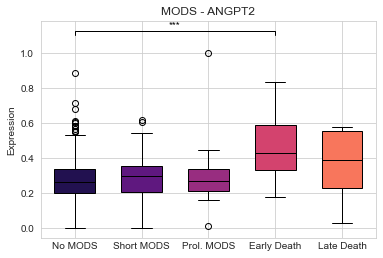

[[(1, 4), 0.0005569540612959855]]


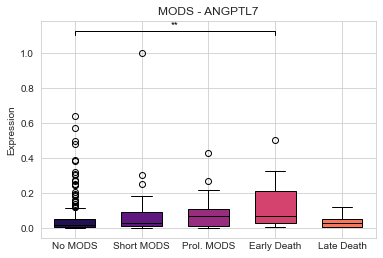

[[(1, 4), 1.4601509902216402e-08], [(1, 3), 7.212746285447077e-05], [(2, 4), 0.0003415237161208388], [(1, 2), 5.074046105606032e-08]]


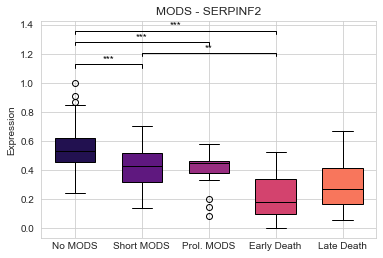

[[(1, 5), 0.00015328793651029306], [(1, 4), 5.368188796884446e-06], [(1, 2), 0.0003586564803122125]]


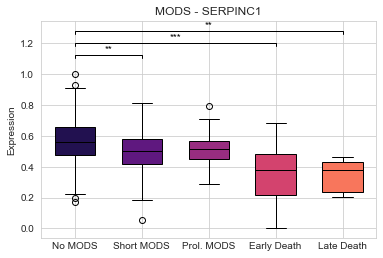

[[(1, 4), 1.2555693741277577e-05]]


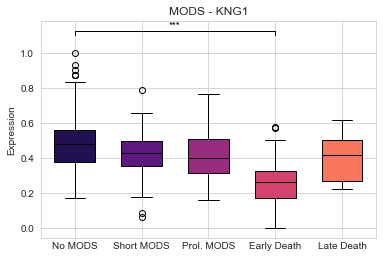

[[(1, 4), 2.877428825352889e-05], [(1, 2), 0.0003703257919685098]]


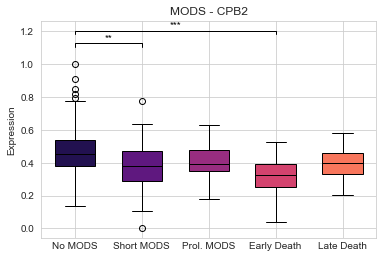

[[(1, 4), 9.763149874124914e-06], [(1, 2), 7.96803535657747e-06]]


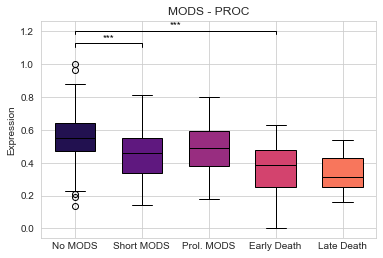

In [57]:
# print all agptl proteins 
angiop=['ANGPTL4.3796.79', 'ANGPT4.2500.2', 'ANGPT2.2602.2', 'ANGPTL7.6371.50', 
'SERPINF2.3024.18', 'SERPINC1.3344.60', 'KNG1.7784.1', 'CPB2.3518.54', 'PROC.2961.1']
for i in angiop:
    plot_graph_prot(i) 

[[(1, 4), 4.948361702601623e-05]]


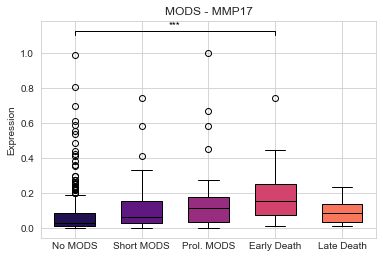

In [53]:
# high MMPS at admission in patients with early death
# 'MMP13.4925.54',
#        'MMP16.5268.49',
plot_graph_prot('MMP17.2838.53') 

In [ ]:
#########

[[(1, 5), 0.0004219609025328873], [(1, 4), 0.00024471323894046504]]


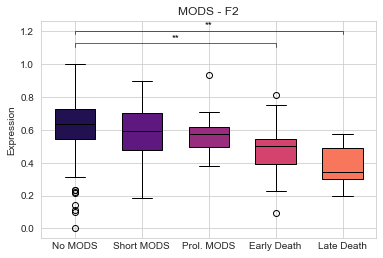

In [23]:
#pro-thrombin
plot_graph_prot('F2.5316.54') 

[[(1, 4), 2.393755693753219e-05], [(2, 4), 9.695194211877711e-06]]


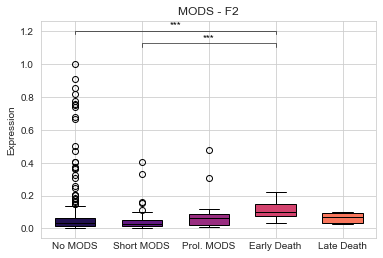

In [24]:
# thrombin
plot_graph_prot('F2.4157.2')

[]


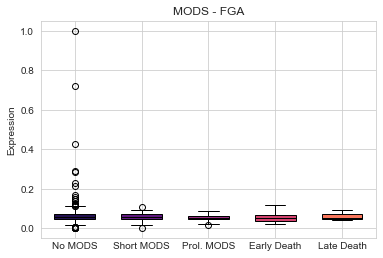

In [48]:
plot_graph_prot('FGA.FGB.FGG.4907.56')

[[(1, 4), 8.968561995639167e-10], [(1, 3), 3.837483027415446e-08], [(2, 4), 3.6689582450981847e-06], [(1, 2), 3.514301340913145e-06]]


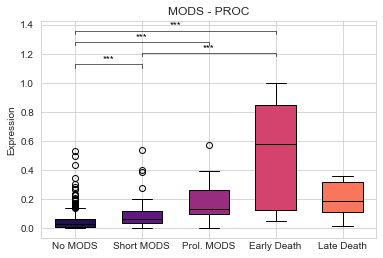

In [25]:
plot_graph_prot('PROC.3758.68') 

[[(1, 4), 5.895033267822558e-09], [(2, 4), 8.961914629971641e-05], [(1, 2), 4.230532462435827e-06], [(3, 4), 0.0003818798425058117]]


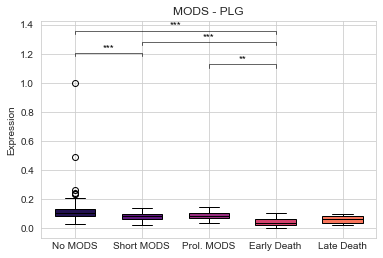

In [26]:
plot_graph_prot('PLG.4151.6')

[[(1, 4), 2.058215018151906e-06]]


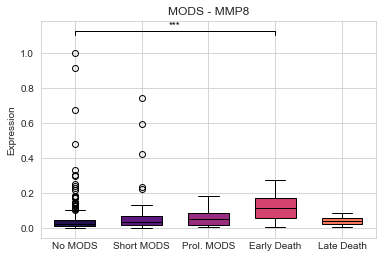

[[(1, 2), 1.0070740501654056e-05]]


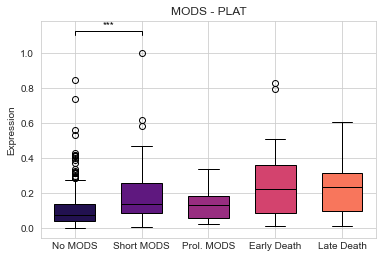

In [49]:
plot_graph_prot('MMP8.9172.69',) 
plot_graph_prot('PLAT.2212.69') 


In [28]:
endot_df[endot_df['combination']==(1,5)]['name']

36    SERPINC1.3344.60
47          F2.5316.54
50          F7.3184.25
Name: name, dtype: object

[[(1, 3), 0.00022641727730989523]]


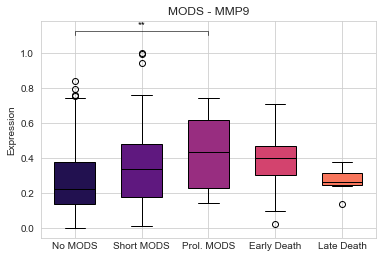

In [29]:
plot_graph_prot('MMP9.2579.17') 

[[(1, 4), 5.5296780543626045e-05], [(1, 2), 7.672151297636088e-05]]


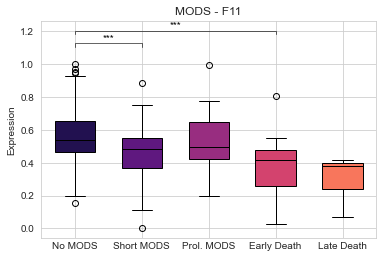

[[(1, 5), 0.0003110642469419345]]


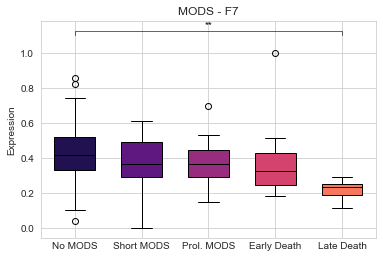

[[(1, 5), 0.0003110642469419345]]


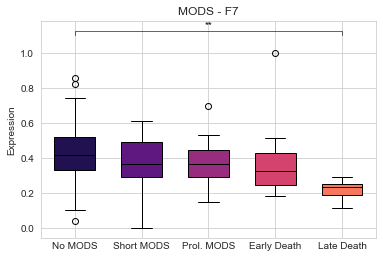

In [30]:
### proteins that decrease in early death
### panel for the appendix

plot_graph_prot('F11.2190.55') 
plot_graph_prot('F7.3184.25') 
plot_graph_prot('F7.3184.25') 